Section 1: Dataset Overview

In [1]:
import pandas as pd
import numpy as np

books = pd.read_csv("../data/processed/books_master.csv")
ratings = pd.read_csv("../data/processed/ratings_master.csv")

C:\Users\anshu\AppData\Local\Temp\ipykernel_7820\4167792585.py:4: DtypeWarning: Columns (0: Year-Of-Publication) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("../data/processed/books_master.csv")


In [2]:
print("Books Shape:", books.shape)
print("Ratings Shape:", ratings.shape)

Books Shape: (271360, 13)
Ratings Shape: (1149780, 3)


In [3]:
n_users = ratings["User-ID"].nunique()

print("Unique Users:", n_users)

Unique Users: 105283


In [4]:
n_books = ratings["ISBN"].nunique()

print("Unique Books Rated:", n_books)

Unique Books Rated: 340556


In [5]:
n_ratings = len(ratings)

print("Total Ratings:", n_ratings)

Total Ratings: 1149780


In [6]:
overview = pd.DataFrame({
    "Metric": [
        "Unique Users",
        "Unique Rated Books",
        "Total Ratings"
    ],
    "Value": [
        n_users,
        n_books,
        n_ratings
    ]
})

overview

,Metric,Value
0,Unique Users,105283
1,Unique Rated Books,340556
2,Total Ratings,1149780


In [7]:
catalog_books = set(books["ISBN"])

rated_books = set(ratings["ISBN"])

print("Books in catalog:", len(catalog_books))
print("Books in ratings:", len(rated_books))

print(
    "Rated books missing from catalog:",
    len(rated_books - catalog_books)
)

Books in catalog: 271360
Books in ratings: 340556
Rated books missing from catalog: 70405


In [8]:
valid_ratings = ratings[
    ratings["ISBN"].isin(
        books["ISBN"]
    )
]

print("Original Ratings:", len(ratings))
print("Valid Ratings:", len(valid_ratings))

print(
    "Ratings Removed:",
    len(ratings) - len(valid_ratings)
)

Original Ratings: 1149780
Valid Ratings: 1031136
Ratings Removed: 118644


In [9]:
ratings_master = ratings[
    ratings["ISBN"].isin(
        books["ISBN"]
    )
].copy()

In [10]:
print(ratings_master.shape)

(1031136, 3)


In [11]:
ratings_master.to_csv(
    "../data/processed/ratings_master.csv",
    index=False
)

In [12]:
ratings_master["Rating"].describe()

count    1.031136e+06
mean     2.839051e+00
std      3.854157e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      7.000000e+00
max      1.000000e+01
Name: Rating, dtype: float64

In [13]:
ratings_master["Rating"].value_counts().sort_index()

Rating
0     647294
1       1481
2       2375
3       5118
4       7617
5      45355
6      31687
7      66402
8      91804
9      60778
10     71225
Name: count, dtype: int64

In [16]:
explicit_ratings = ratings_master[
    ratings_master["Rating"] > 0
].copy()

print("Explicit Ratings:", len(explicit_ratings))

print("Unique Users:",
      explicit_ratings["User-ID"].nunique())

print("Unique Books:",
      explicit_ratings["ISBN"].nunique())

Explicit Ratings: 383842
Unique Users: 68091
Unique Books: 149836


In [17]:
n_users = explicit_ratings["User-ID"].nunique()

n_books = explicit_ratings["ISBN"].nunique()

n_ratings = len(explicit_ratings)

possible_interactions = n_users * n_books

sparsity = (
    1 - (n_ratings / possible_interactions)
) * 100

print(f"Sparsity: {sparsity:.4f}%")

Sparsity: 99.9962%


In [18]:
user_activity = (
    explicit_ratings
    .groupby("User-ID")
    .size()
)

user_activity.describe()

count    68091.000000
mean         5.637191
std         41.742511
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       6943.000000
dtype: float64

In [19]:
print("Users with 1 rating:",
      (user_activity == 1).sum())

print("Users with <= 3 ratings:",
      (user_activity <= 3).sum())

print("Users with >= 50 ratings:",
      (user_activity >= 50).sum())

Users with 1 rating: 39223
Users with <= 3 ratings: 52472
Users with >= 50 ratings: 1180


In [20]:
book_activity = (
    explicit_ratings
    .groupby("ISBN")
    .size()
)

book_activity.describe()

count    149836.000000
mean          2.561748
std           7.505562
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         707.000000
dtype: float64

In [21]:
print("Books with 1 rating:",
      (book_activity == 1).sum())

print("Books with <= 3 ratings:",
      (book_activity <= 3).sum())

print("Books with >= 50 ratings:",
      (book_activity >= 50).sum())

Books with 1 rating: 99413
Books with <= 3 ratings: 131137
Books with >= 50 ratings: 531


In [23]:
matched_isbns = set(
    books[
        books["description"].notna()
    ]["ISBN"]
)

In [24]:
matched_book_ratings = (
    explicit_ratings[
        explicit_ratings["ISBN"].isin(matched_isbns)
    ]
    .groupby("ISBN")
    .size()
)

In [25]:
all_book_ratings = (
    explicit_ratings
    .groupby("ISBN")
    .size()
)

In [26]:
print("All Books")
print(all_book_ratings.describe())

print("\nMatched Books")
print(matched_book_ratings.describe())

All Books
count    149836.000000
mean          2.561748
std           7.505562
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         707.000000
dtype: float64

Matched Books
count    529.000000
mean      15.007561
std       36.356035
min        1.000000
25%        1.000000
50%        3.000000
75%       13.000000
max      487.000000
dtype: float64


In [27]:
enriched_ratings = explicit_ratings[
    explicit_ratings["ISBN"].isin(matched_isbns)
]

print("Ratings:", len(enriched_ratings))

print("Users:",
      enriched_ratings["User-ID"].nunique())

print("Books:",
      enriched_ratings["ISBN"].nunique())

Ratings: 7939
Users: 5184
Books: 529


In [28]:
top_enriched_books = (
    enriched_ratings["ISBN"]
    .value_counts()
    .head(20)
)

top_enriched_books

ISBN
0385504209    487
044023722X    281
044021145X    208
0440241073    200
0440211727    194
0440234743    169
0440221471    152
0380789035    151
0440220602    146
0440224764    143
044022165X    138
0440225701    133
0380789019    126
0449212602    111
0385503822    107
0671027387     93
0446611212     92
067102423X     90
0441003257     87
038550120X     81
Name: count, dtype: int64

In [29]:
books.set_index("ISBN").loc[
    top_enriched_books.index,
    ["Book-Title", "Book-Author"]
]

,Book-Title,Book-Author
ISBN,,
0385504209,The Da Vinci Code,Dan Brown
044023722X,A Painted House,John Grisham
044021145X,The Firm,John Grisham
0440241073,The Summons,John Grisham
0440211727,A Time to Kill,JOHN GRISHAM
0440234743,The Testament,John Grisham
0440221471,The Runaway Jury,JOHN GRISHAM
0380789035,American Gods,Neil Gaiman
0440220602,The Chamber,John Grisham


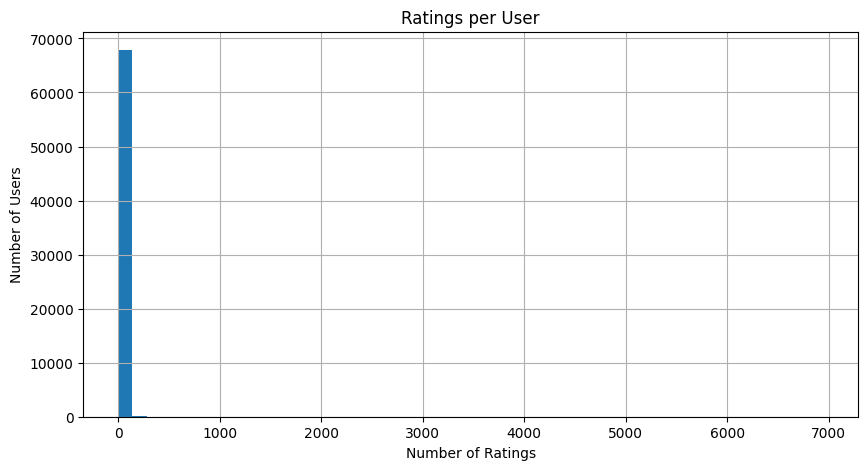

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

user_activity.hist(bins=50)

plt.title("Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.show()

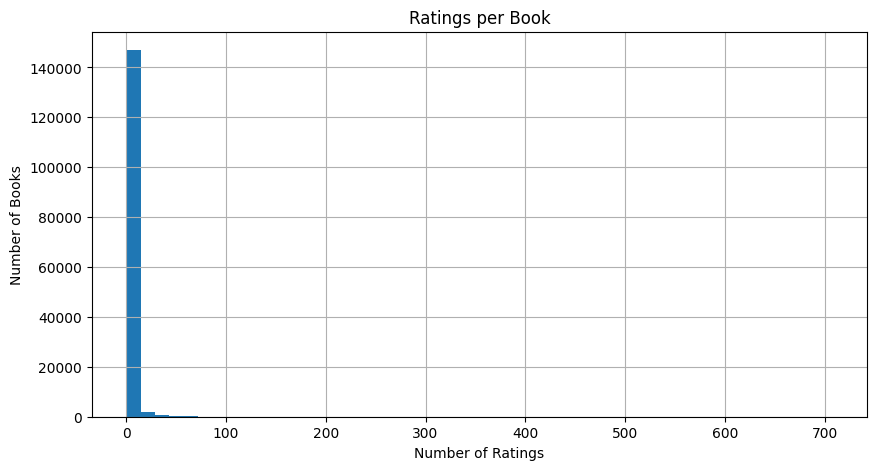

In [31]:
plt.figure(figsize=(10, 5))

book_activity.hist(bins=50)

plt.title("Ratings per Book")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Books")

plt.show()

In [32]:
cold_users = (user_activity == 1).sum()

cold_user_pct = (
    cold_users / len(user_activity)
) * 100

print(f"Cold Users: {cold_users}")
print(f"Percentage: {cold_user_pct:.2f}%")

Cold Users: 39223
Percentage: 57.60%


In [33]:
cold_books = (book_activity == 1).sum()

cold_book_pct = (
    cold_books / len(book_activity)
) * 100

print(f"Cold Books: {cold_books}")
print(f"Percentage: {cold_book_pct:.2f}%")

Cold Books: 99413
Percentage: 66.35%


In [34]:
metadata_summary = pd.DataFrame({
    "Field": [
        "Description",
        "Categories",
        "Language",
        "Page Count",
        "Thumbnail"
    ],
    "Coverage": [
        books["description"].notna().sum(),
        books["categories"].notna().sum(),
        books["language"].notna().sum(),
        books["page_count"].notna().sum(),
        books["thumbnail"].notna().sum()
    ]
})

metadata_summary

,Field,Coverage
0,Description,692
1,Categories,700
2,Language,746
3,Page Count,742
4,Thumbnail,721


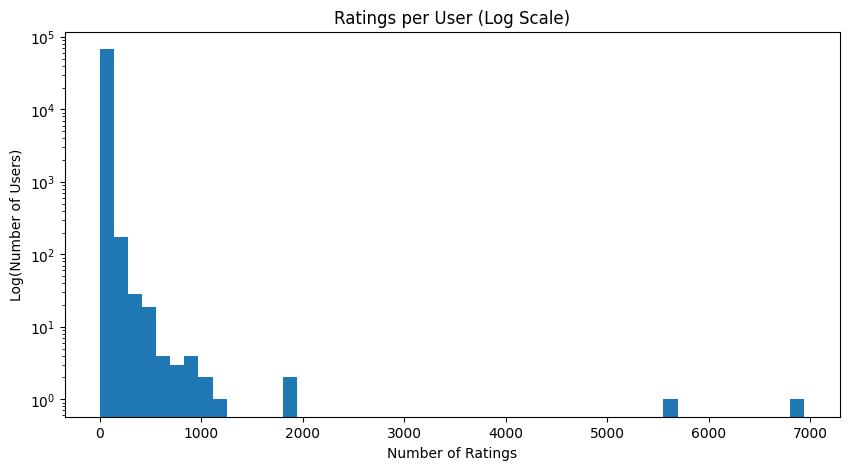

In [35]:
plt.figure(figsize=(10,5))

plt.hist(
    user_activity,
    bins=50,
    log=True
)

plt.title("Ratings per User (Log Scale)")
plt.xlabel("Number of Ratings")
plt.ylabel("Log(Number of Users)")

plt.show()

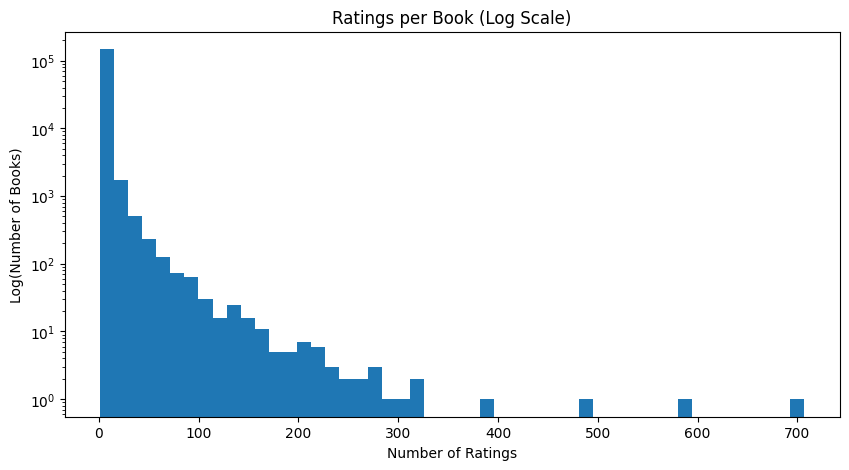

In [36]:
plt.figure(figsize=(10,5))

plt.hist(
    book_activity,
    bins=50,
    log=True
)

plt.title("Ratings per Book (Log Scale)")
plt.xlabel("Number of Ratings")
plt.ylabel("Log(Number of Books)")

plt.show()
